# AI Consumer Behavior Prediction System

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import pickle

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Load Dataset

In [2]:
from google.colab import files
uploaded = files.upload()

Saving amazon_reviews.csv to amazon_reviews (1).csv


In [3]:
df_original = pd.read_csv("amazon_reviews.csv")

df = df_original.copy()

In [4]:
import pandas as pd

df = pd.read_csv("amazon_reviews.csv")
df.head()

,id,asins,brand,categories,colors,dateAdded,dateUpdated,dimension,ean,keys,...,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sizes,upc,weight
0,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I initially had trouble deciding between the p...,"Paperwhite voyage, no regrets!",NaN,NaN,Cristina M,NaN,NaN,205 grams
1,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,Allow me to preface this with a little history...,One Simply Could Not Ask For More,NaN,NaN,Ricky,NaN,NaN,205 grams
2,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,4.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I am enjoying it so far. Great for reading. Ha...,Great for those that just want an e-reader,NaN,NaN,Tedd Gardiner,NaN,NaN,205 grams
3,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I bought one of the first Paperwhites and have...,Love / Hate relationship,NaN,NaN,Dougal,NaN,NaN,205 grams
4,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I have to say upfront - I don't like coroporat...,I LOVE IT,NaN,NaN,Miljan David Tanic,NaN,NaN,205 grams


In [5]:
df.columns

Index(['id', 'asins', 'brand', 'categories', 'colors', 'dateAdded',
       'dateUpdated', 'dimension', 'ean', 'keys', 'manufacturer',
       'manufacturerNumber', 'name', 'prices', 'reviews.date',
       'reviews.doRecommend', 'reviews.numHelpful', 'reviews.rating',
       'reviews.sourceURLs', 'reviews.text', 'reviews.title',
       'reviews.userCity', 'reviews.userProvince', 'reviews.username', 'sizes',
       'upc', 'weight'],
      dtype='object')

In [6]:
df = df[['reviews.text', 'reviews.rating', 'reviews.doRecommend']]

df = df.dropna()

df.columns = ['review', 'rating', 'recommended']

df.head()

,review,rating,recommended
855,Look at this product as a portable speaker fir...,5.0,True
856,This Amazon tap is not only a great Bluetooth ...,5.0,True
857,Bought this on Deal of the Day which surprised...,5.0,True
858,Amazing Sound! All around great product! Nothi...,5.0,True
859,I have owned the Echo for about a year now and...,5.0,True


# Feature Engineering

Additional features are created to improve model performance:
- Sentiment Labels
- Review Length
- Sentiment Score
- Purchase Recommendation Label

In [7]:
def get_sentiment(rating):
    if rating >= 4:
        return "positive"
    elif rating == 3:
        return "neutral"
    else:
        return "negative"

df['sentiment'] = df['rating'].apply(get_sentiment)

In [8]:
# Review Length
df['review_length'] = df['review'].apply(
    lambda x: len(str(x).split())
)

In [9]:
#Sentiment Score
def sentiment_score(label):
    if label == "positive":
        return 1
    elif label == "neutral":
        return 0
    else:
        return -1

df['sentiment_score'] = df['sentiment'].apply(sentiment_score)

In [10]:
# Purchase Label
df['purchase_label'] = df['recommended'].apply(
    lambda x: 1 if x == True else 0
)

print(df.head())

                                                review  rating recommended  \
855  Look at this product as a portable speaker fir...     5.0        True   
856  This Amazon tap is not only a great Bluetooth ...     5.0        True   
857  Bought this on Deal of the Day which surprised...     5.0        True   
858  Amazing Sound! All around great product! Nothi...     5.0        True   
859  I have owned the Echo for about a year now and...     5.0        True   

    sentiment  review_length  sentiment_score  purchase_label  
855  positive             94                1               1  
856  positive            250                1               1  
857  positive             66                1               1  
858  positive             10                1               1  
859  positive             70                1               1  


# Dataset Balancing

The dataset is balanced to improve prediction fairness and avoid model bias.

In [11]:
# Dataset Balancing
class_0 = df[df['purchase_label'] == 0]
class_1 = df[df['purchase_label'] == 1]

print(len(class_0), len(class_1))

36 503


In [12]:
# Balance Both Classes
class_0_sample = class_0.sample(
    500,
    random_state=42,
    replace=True
)

class_1_sample = class_1.sample(
    500,
    random_state=42
)

df_balanced = pd.concat([
    class_0_sample,
    class_1_sample
])

df_balanced = df_balanced.sample(
    frac=1,
    random_state=42
)

print(df_balanced['purchase_label'].value_counts())

purchase_label
1    500
0    500
Name: count, dtype: int64


# TF-IDF Vectorization

TF-IDF converts textual review data into numerical vectors for machine learning.

In [13]:
# Features and Labels
X = df_balanced['review']
y = df_balanced['purchase_label']

In [14]:
# ================================
# Train Test Split
# ================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
# ================================
# TF-IDF Vectorization
# ================================

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

# Model Training

A Logistic Regression model is trained on vectorized review data.

In [16]:
# ================================
# Logistic Regression Model
# ================================

model = LogisticRegression()

model.fit(X_train_tfidf, y_train)

LogisticRegression()

# Model Evaluation

The trained model is evaluated using:
- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

In [17]:
# Predictions
y_pred = model.predict(X_test_tfidf)

In [18]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.975


In [19]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.98       100
           1       1.00      0.95      0.97       100

    accuracy                           0.97       200
   macro avg       0.98      0.97      0.97       200
weighted avg       0.98      0.97      0.97       200



# Visualizations

Visualizations help understand sentiment distribution and model performance.

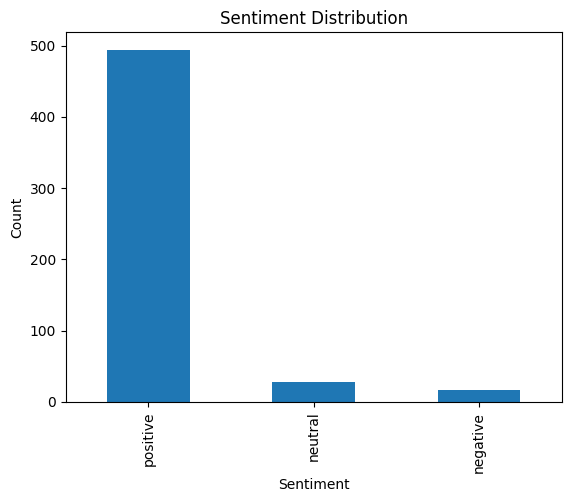

In [20]:
# Sentiment Distribution
df['sentiment'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

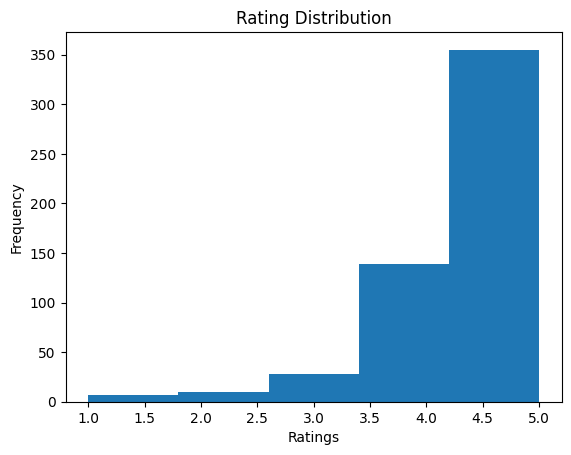

In [21]:
# Rating Distribution
df['rating'].plot(kind='hist', bins=5)

plt.title("Rating Distribution")
plt.xlabel("Ratings")

plt.show()

# Word Cloud Analysis

A word cloud is generated to visualize frequently used review words.

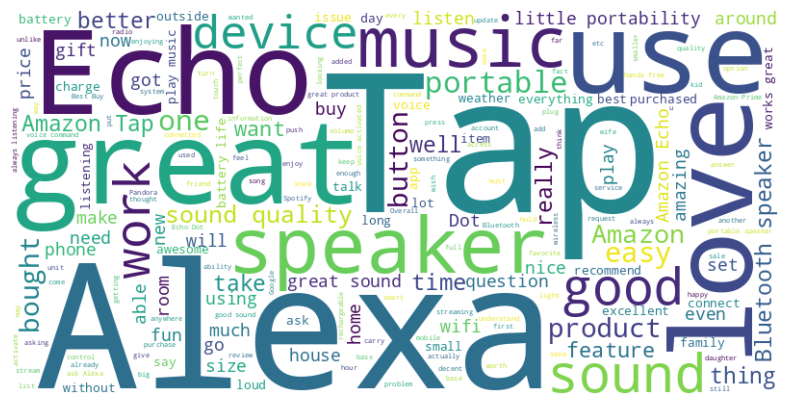

In [22]:
# Word Cloud
text = " ".join(df['review'].astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis("off")

plt.show()

# Confusion Matrix

The confusion matrix visualizes model prediction performance.

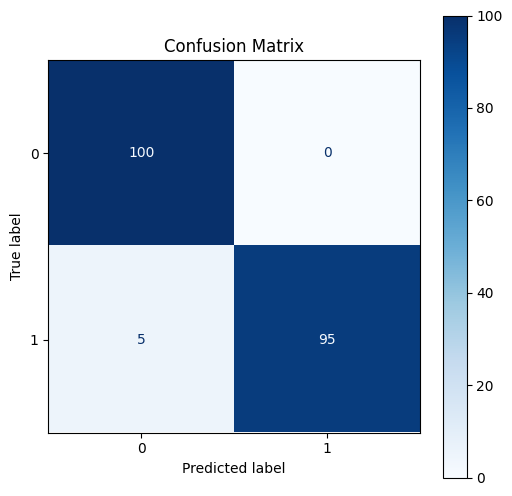

In [23]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(6,6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap='Blues',
    ax=ax
)

plt.title("Confusion Matrix")

plt.show()

# Save Model and Vectorizer

The trained model and TF-IDF vectorizer are saved for deployment in the Streamlit web application.

In [24]:
# Save Model and Vectorizer
pickle.dump(model, open("model.pkl", "wb"))

pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

# Streamlit Web Application

A Streamlit application is created for real-time prediction.

In [29]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 39.3 MB/s eta 0:00:00


In [30]:
# Create Streamlit App
%%writefile app.py

import streamlit as st
import pickle

model = pickle.load(open("model.pkl", "rb"))
vectorizer = pickle.load(open("vectorizer.pkl", "rb"))

st.set_page_config(
    page_title="AI Consumer Behavior Prediction",
    page_icon="🖥️",
    layout="centered"
)

st.title("AI Consumer Behavior Prediction")

st.write(
    "Predict whether consumers are likely to recommend or purchase a product based on review text."
)

review = st.text_area(
    "Enter Product Review",
    placeholder="Example: This product is amazing and worth the price!"
)

if st.button("Predict"):

    if review.strip() == "":
        st.warning("Please enter a review first.")

    else:

        review_vector = vectorizer.transform([review])

        prediction = model.predict(review_vector)[0]

        probability = model.predict_proba(review_vector)[0]

        confidence = max(probability) * 100

        if prediction == 1:
            st.success(
                "Consumers are likely to recommend/purchase this product."
            )
        else:
            st.error(
                "Consumers are unlikely to recommend/purchase this product."
            )

        st.info(
            f"Prediction Confidence: {confidence:.2f}%"
        )

Overwriting app.py


# Run Streamlit Application

In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧

your url is: https://hip-llamas-grab.loca.lt
2026-05-08 08:06:53.133 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://107.167.177.15:8501



In [28]:
df.to_csv("processed_data.csv", index=False)

# Conclusion

This project demonstrates how AI and NLP techniques can be used to analyze customer reviews and predict consumer recommendation behavior using machine learning and interactive deployment.